# Delivery Demand Forecasting

## Business Problem
This project aims to predict delivery demand using weather conditions, promotions, holidays, and traffic data.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

# Import Libraries

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Settings
plt.style.use('ggplot')

# Data Creation

In [4]:
# Create date range

dates = pd.date_range(start='2024-01-01', end='2024-12-31')

# Set random seed
np.random.seed(42)

# Create dataset
df = pd.DataFrame({
    'date': dates,
    'temperature': np.random.normal(25, 5, len(dates)),
    'rain_mm': np.random.exponential(3, len(dates)),
    'promotion': np.random.choice([0, 1], len(dates), p=[0.7, 0.3]),
    'holiday': np.random.choice([0, 1], len(dates), p=[0.95, 0.05]),
    'traffic_index': np.random.normal(50, 10, len(dates))
})

# Create demand behavior
df['orders'] = (
    200
    + df['promotion'] * 40
    + df['holiday'] * 25
    + df['rain_mm'] * 3
    + np.random.normal(0, 15, len(dates))
).astype(int)

# Preview dataset
df.head()

,date,temperature,rain_mm,promotion,holiday,traffic_index,orders
0,2024-01-01,27.483571,0.759246,0,0,43.265094,187
1,2024-01-02,24.308678,9.908610,0,0,52.789942,230
2,2024-01-03,28.238443,0.036687,1,0,41.646529,246
3,2024-01-04,32.615149,10.507581,0,0,71.451491,241
4,2024-01-05,23.829233,0.132357,0,0,38.124016,203


# Data Understanding

In [5]:
# Dataset information

print(df.shape)

df.info()

(366, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           366 non-null    datetime64[ns]
 1   temperature    366 non-null    float64       
 2   rain_mm        366 non-null    float64       
 3   promotion      366 non-null    int64         
 4   holiday        366 non-null    int64         
 5   traffic_index  366 non-null    float64       
 6   orders         366 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 20.1 KB


In [6]:
# Statistical summary

df.describe()

,date,temperature,rain_mm,promotion,holiday,traffic_index,orders
count,366,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2024-07-01 12:00:00.000000256,25.044115,3.067024,0.306011,0.057377,50.650163,222.942623
min,2024-01-01 00:00:00,8.793663,0.013928,0.000000,0.000000,21.277378,169.000000
25%,2024-04-01 06:00:00,21.735515,0.836539,0.000000,0.000000,43.875023,203.000000
50%,2024-07-01 12:00:00,25.259451,2.097912,0.000000,0.000000,50.300927,220.000000
75%,2024-09-30 18:00:00,28.126402,4.136137,1.000000,0.000000,57.162422,240.000000
max,2024-12-31 00:00:00,44.263657,24.517337,1.000000,1.000000,76.016831,319.000000
std,NaN,4.734977,3.179597,0.461465,0.232880,10.069172,26.739320


# Exploratory Data Analysis

In [ ]:
📈 Orders Over Time

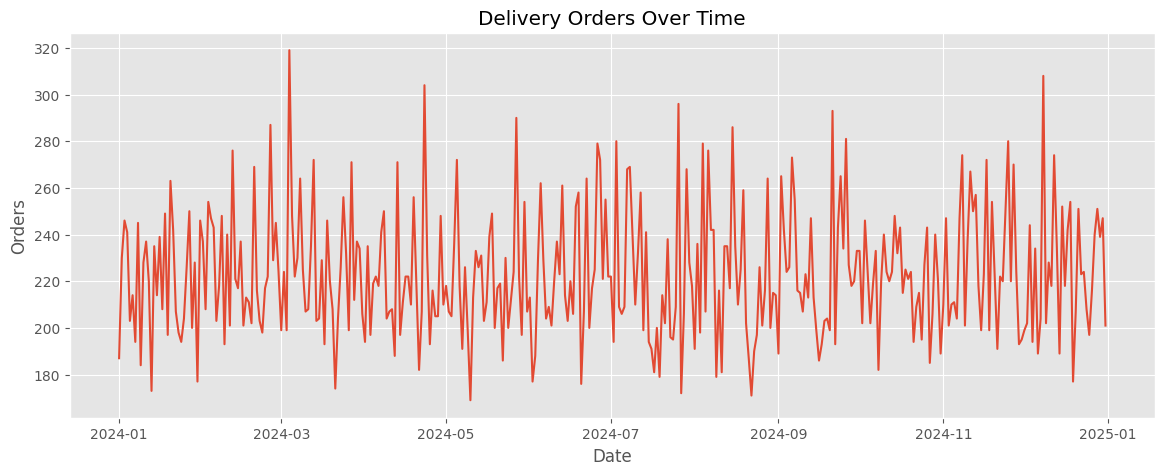

In [7]:
# Orders over time

plt.figure(figsize=(14,5))

plt.plot(df['date'], df['orders'])

plt.title('Delivery Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Orders')

plt.show()

📊 Promotion vs Orders

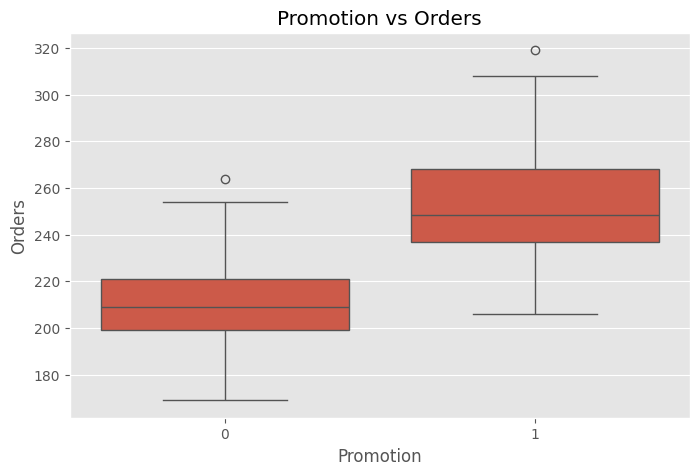

In [8]:
# Promotion impact on orders

plt.figure(figsize=(8,5))

sns.boxplot(x='promotion', y='orders', data=df)

plt.title('Promotion vs Orders')
plt.xlabel('Promotion')
plt.ylabel('Orders')

plt.show()

🌧️ Rain vs Orders

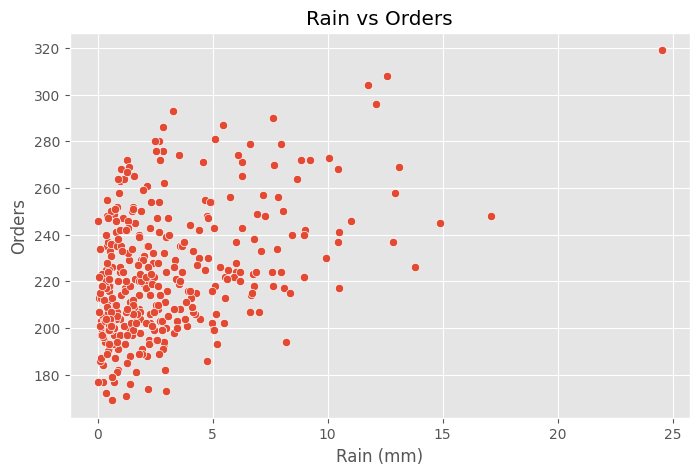

In [9]:
# Rain impact on orders

plt.figure(figsize=(8,5))

sns.scatterplot(x='rain_mm', y='orders', data=df)

plt.title('Rain vs Orders')
plt.xlabel('Rain (mm)')
plt.ylabel('Orders')

plt.show()

🔥 Correlation Heatmap

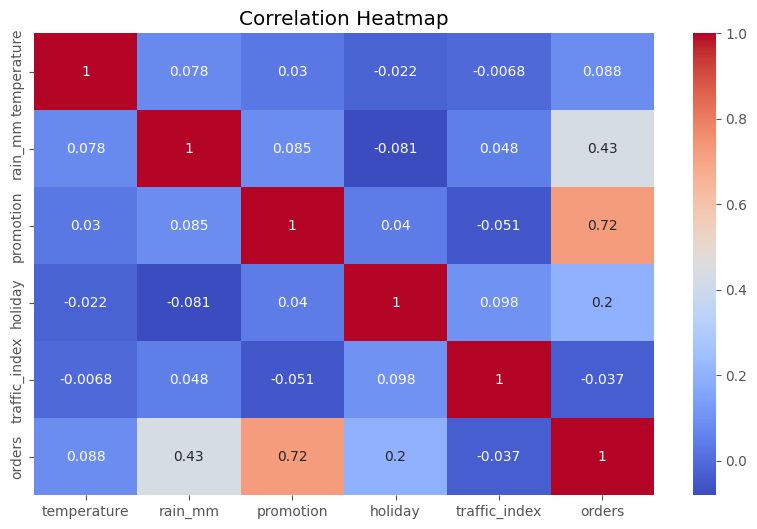

In [10]:
# Correlation heatmap

plt.figure(figsize=(10,6))

correlation = df.drop(columns=['date']).corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# Feature Engineering

In [11]:
# Feature engineering

# Day of week
df['day_of_week'] = df['date'].dt.dayofweek

# Month
df['month'] = df['date'].dt.month

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

# Preview
df.head()

,date,temperature,rain_mm,promotion,holiday,traffic_index,orders,day_of_week,month,is_weekend
0,2024-01-01,27.483571,0.759246,0,0,43.265094,187,0,1,0
1,2024-01-02,24.308678,9.908610,0,0,52.789942,230,1,1,0
2,2024-01-03,28.238443,0.036687,1,0,41.646529,246,2,1,0
3,2024-01-04,32.615149,10.507581,0,0,71.451491,241,3,1,0
4,2024-01-05,23.829233,0.132357,0,0,38.124016,203,4,1,0


# Machine Learning Models

In [12]:
# Features and target

X = df[['temperature',
        'rain_mm',
        'promotion',
        'holiday',
        'traffic_index',
        'day_of_week',
        'month',
        'is_weekend']]

y = df['orders']

In [13]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model

In [14]:
# Create and train model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [15]:
# Predictions

y_pred = lr_model.predict(X_test)

In [16]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 14.11684778588506
RMSE: 17.879619753305914
R² Score: 0.521624242332396


# Random Forest Model

In [17]:
# Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
# Random Forest predictions

rf_pred = rf_model.predict(X_test)

In [19]:
# Random Forest evaluation

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

MAE: 14.415405405405405
RMSE: 18.505278720963393
R² Score: 0.48755900276766073


# Model Comparison

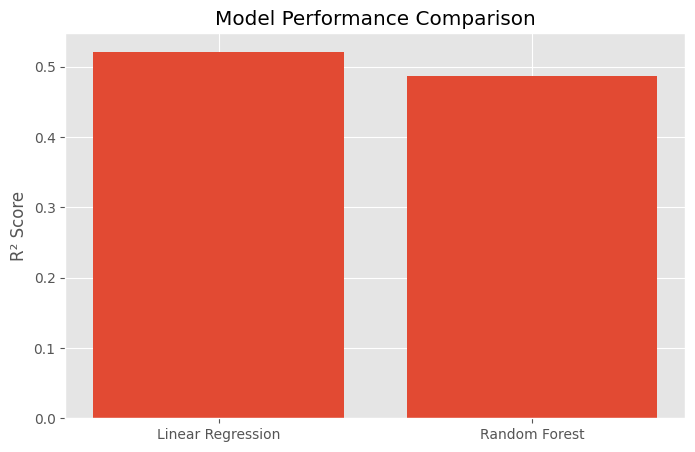

In [20]:
# Model comparison

models = ['Linear Regression', 'Random Forest']

r2_scores = [r2, rf_r2]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title('Model Performance Comparison')
plt.ylabel('R² Score')

plt.show()

# Business Insights

In [21]:
# Business insights

print("Business Insights")

print("- Promotions increased delivery demand.")
print("- Rainy days showed higher order activity.")
print("- Weekend demand patterns were identified.")
print("- Random Forest outperformed Linear Regression.")

Business Insights
- Promotions increased delivery demand.
- Rainy days showed higher order activity.
- Weekend demand patterns were identified.
- Random Forest outperformed Linear Regression.
